In [11]:
import sys
import os
import pandas as pd 

sys.path.append(os.path.abspath('..'))

In [12]:
from src.entrada_saida import carregar_dados_brutos
from src.visualizacao import configurar_estilo, plotar_sazonalidade, plotar_ranking_cidades
df = carregar_dados_brutos("../data/RECLAMEAQUI_HAPVIDA_LIMPO.csv")

# Análise Descritiva Preliminar

## Frequência por STATUS

In [13]:

display(df['STATUS'].value_counts().reset_index(name='TOTAL'))

,STATUS,TOTAL
0,Não respondida,639
1,Respondida,271
2,Resolvido,67
3,Em réplica,36
4,Não resolvido,3


## Tamanho das reclamações

In [14]:
df['DESCRICAO'].str.len().describe()

count     1016.000000
mean       455.070866
std        514.344278
min          7.000000
25%        212.750000
50%        354.500000
75%        573.500000
max      12800.000000
Name: DESCRICAO, dtype: float64

## Frequência por categoria

In [15]:
display(df['TIPO_SERVICO'].value_counts().reset_index(name='TOTAL'))

,TIPO_SERVICO,TOTAL
0,ATENDIMENTO,388
1,AGENDAMENTO,271
2,EXAMES / PROCEDIMENTOS,117
3,OUTROS,90
4,FINANCEIRO,72
5,AUTORIZAÇÃO,45
6,ADMINISTRATIVO,29
7,ESTRUTURA / REDE,3
8,INFORMAÇÃO,1


## Sazonalidade

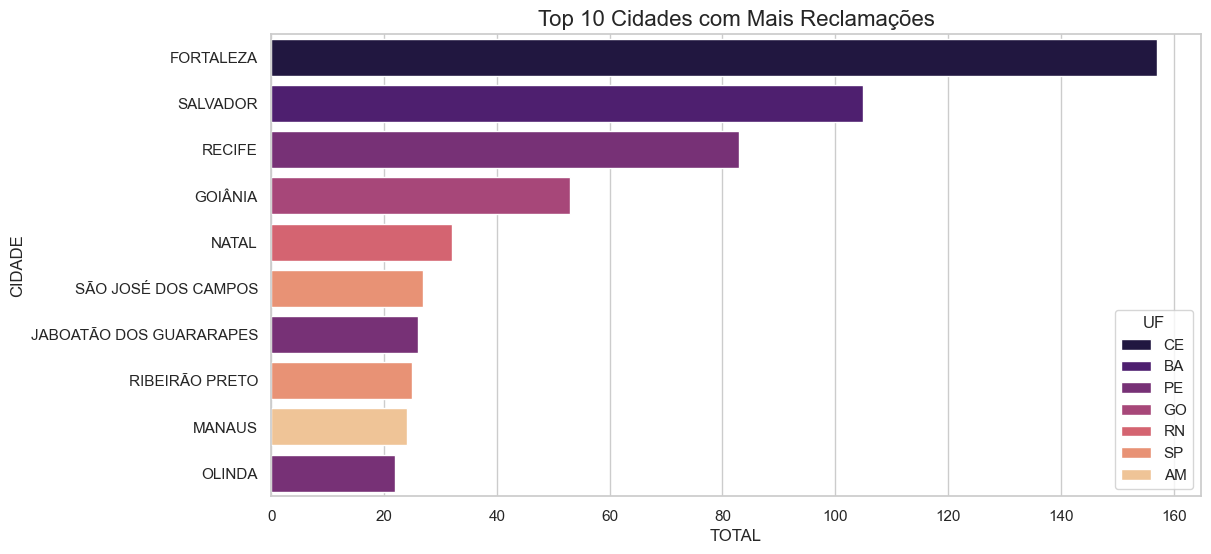

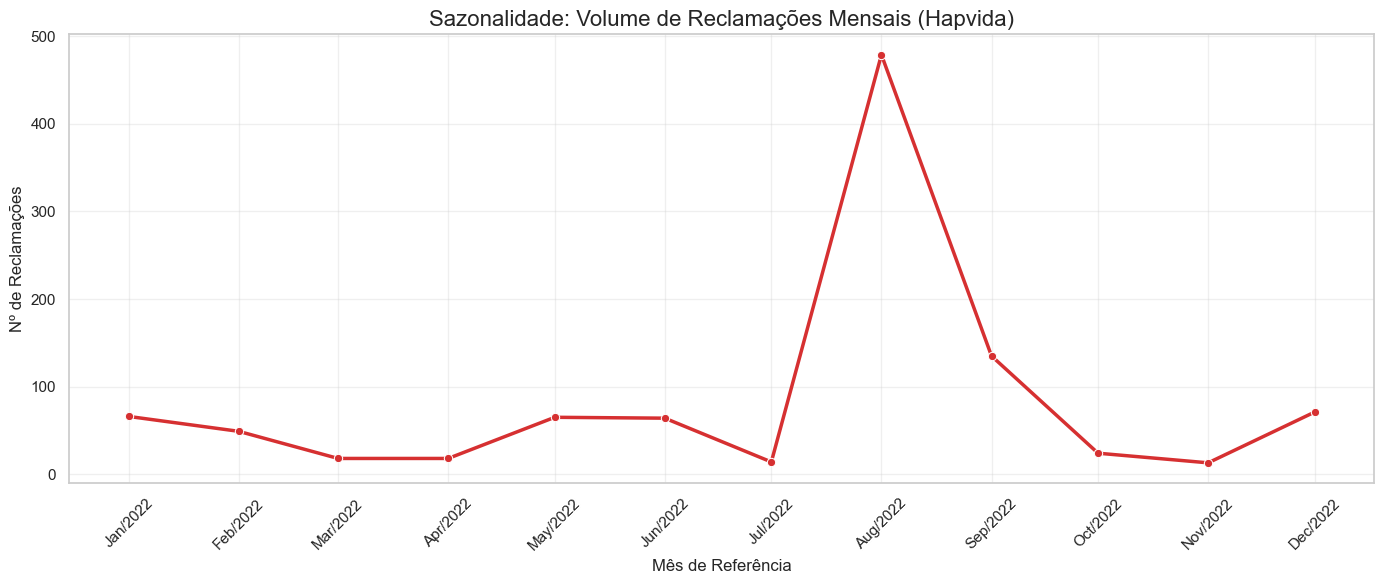

In [16]:
df['DATA'] = pd.to_datetime(df['DATA'])
configurar_estilo()

plotar_ranking_cidades(df)
plotar_sazonalidade(df)

## KPIs Obrigatorios para o Dashboard

Nesta secao, sao geradas as evidencias de: serie temporal com media movel, mapa geografico com seletor de ano e distribuicao de tamanho de texto por STATUS.


In [17]:
from src.visualizacao import (
    plotar_serie_temporal_media_movel,
    plotar_mapa_geografico_por_ano,
    plotar_distribuicao_tamanho_texto_status,
)


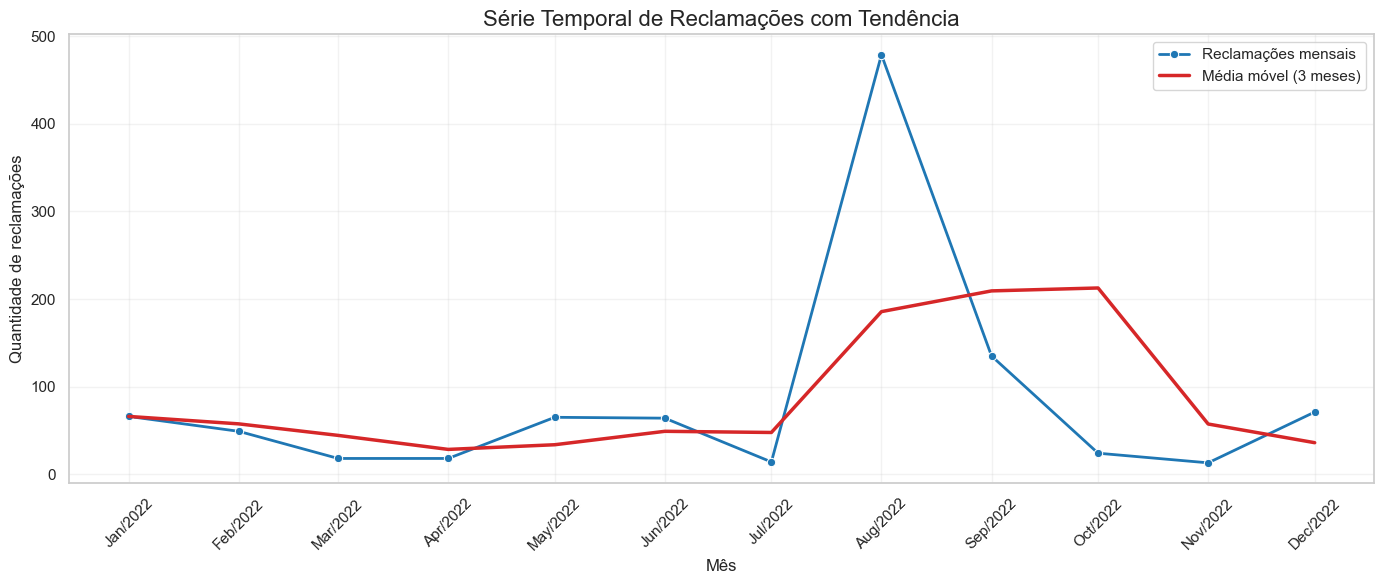

In [18]:
plotar_serie_temporal_media_movel(df, janela=3)


In [19]:
fig_mapa = plotar_mapa_geografico_por_ano(df)
fig_mapa.show()


In [20]:
fig_box = plotar_distribuicao_tamanho_texto_status(df, tipo='boxplot')
fig_box.show()

fig_hist = plotar_distribuicao_tamanho_texto_status(df, tipo='histograma', bins=25)
fig_hist.show()


## Evolução da Taxa de Omissão / Negligência

Esta KPI mostra os clientes que foram "abandonados". É um indicador importante pois, quando muito alto no Reclame Aqui, prejudica significativamente a reputação da empresa.

**Como calcular:** `(Total de Reclamações com STATUS = 'Não respondida' / Total de Reclamações) * 100`

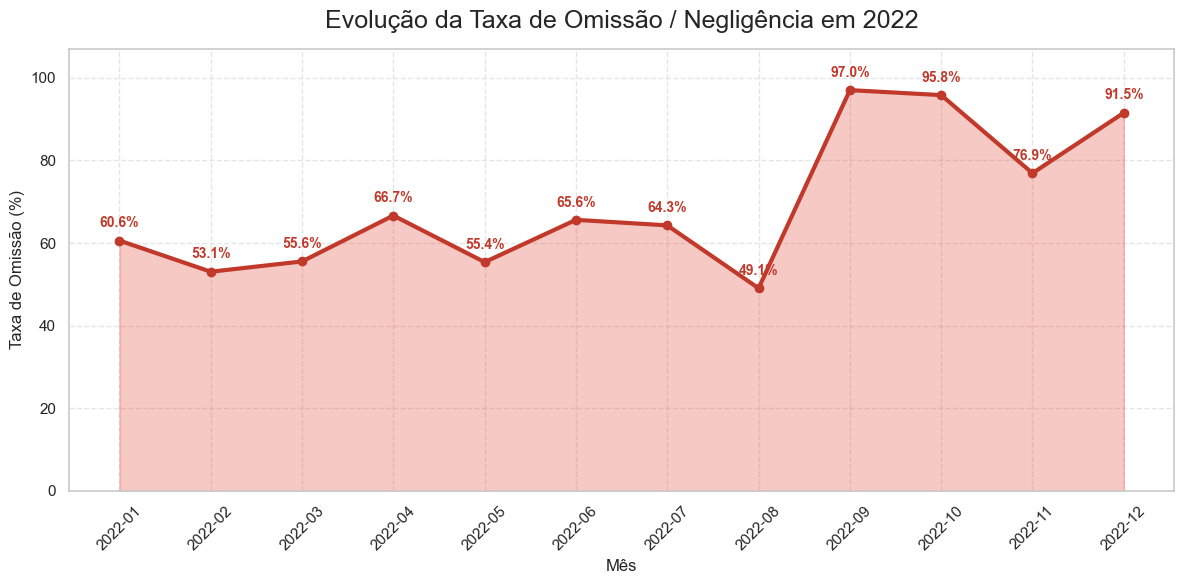

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar para o ano de 2022
df_2022 = df[df['DATA'].dt.year == 2022].copy()

if df_2022.empty:
    print("Não há dados para o ano de 2022 no dataset.")
else:
    # Extrair o Mês/Ano
    df_2022['MES'] = df_2022['DATA'].dt.to_period('M')
    
    # Calcular totais por mês
    total_reclamacoes = df_2022.groupby('MES').size()
    
    # Calcular total de não respondidas por mês
    nao_respondidas = df_2022[df_2022['STATUS'] == 'Não respondida'].groupby('MES').size()
    
    # Consolidar em um DataFrame com preenchimento de zeros onde faltar dado
    df_taxa = pd.DataFrame({'Total': total_reclamacoes, 'Nao Respondida': nao_respondidas}).fillna(0)
    
    # Calcular a Taxa de Omissão em %
    df_taxa['Taxa de Omissao (%)'] = (df_taxa['Nao Respondida'] / df_taxa['Total']) * 100
    
    # Converter o índice para string para exibição correta no eixo X
    df_taxa.index = df_taxa.index.astype(str)
    
    # Criar a figura para o gráfico de área
    plt.figure(figsize=(12, 6))
    
    # Preencher a área (gráfico de área)
    plt.fill_between(df_taxa.index, df_taxa['Taxa de Omissao (%)'], color="#e74c3c", alpha=0.3)
    
    # Linha demarcando topo da área
    plt.plot(df_taxa.index, df_taxa['Taxa de Omissao (%)'], color="#c0392b", linewidth=3, marker='o')
    
    # Estilização do gráfico
    plt.title('Evolução da Taxa de Omissão / Negligência em 2022', fontsize=18, pad=15)
    plt.xlabel('Mês', fontsize=12)
    plt.ylabel('Taxa de Omissão (%)', fontsize=12)
    plt.xticks(rotation=45)
    
    # Ajustar Limites do eixo Y
    y_max = max(100, df_taxa['Taxa de Omissao (%)'].max() + 10) if not df_taxa.empty else 100
    plt.ylim(0, y_max)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    
    # Anotar valores exatos em cada ponto
    for i, taxa in enumerate(df_taxa['Taxa de Omissao (%)']):
        plt.text(i, taxa + 2.5, f"{taxa:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold', color="#c0392b")
        
    plt.show()